# Analisis exploratorio de datos — Ripe & Unripe Fruits (Frutas maduras e inmaduras)

Dataset: 22 clases (11 frutas × ripe/unripe). Fuente: [Kaggle - Fruit Image Dataset 22 classes](https://www.kaggle.com/datasets/mdsagorahmed/fruit-image-dataset-22-classes/data).


In [16]:
import os
import hashlib
import collections
import random
import statistics

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

Ruta_imagenes = "Ripe & Unripe Fruits"
random.seed(0)


## 1. Conteo de imágenes por clase

In [17]:
conteo = {}
for clase in sorted(os.listdir(Ruta_imagenes)):
    ruta_clase = os.path.join(Ruta_imagenes, clase)
    if not os.path.isdir(ruta_clase):
        continue
    conteo[clase] = len(os.listdir(ruta_clase))

conteo_df = pd.DataFrame(sorted(conteo.items()), columns=["clase", "n_imagenes"])
conteo_df


,clase,n_imagenes
0,ripe apple,388
1,ripe banana,400
2,ripe dragon,399
3,ripe grapes,398
4,ripe lemon,386
5,ripe mango,399
6,ripe orange,400
7,ripe papaya,400
8,ripe pineapple,400
9,ripe pomegranate,390


In [18]:
total = conteo_df.n_imagenes.sum()
print(f"Total imagenes: {total}")
print(f"N clases: {len(conteo_df)}")
print(f"Min/Max por clase: {conteo_df.n_imagenes.min()} / {conteo_df.n_imagenes.max()}")


Total imagenes: 8713
N clases: 22
Min/Max por clase: 380 / 400


In [19]:
# Balance ripe madura vs unripe inmadura por fruta
filas = []
for clase, n in conteo.items():
    estado, fruta = clase.split(" ", 1)
    filas.append({"fruta": fruta, "estado": estado, "n": n})
balance_df = pd.DataFrame(filas)
tabla_pivote = balance_df.pivot(index="fruta", columns="estado", values="n").sort_index()
tabla_pivote


estado,ripe,unripe
fruta,,
apple,388,391
banana,400,400
dragon,399,400
grapes,398,397
lemon,386,396
mango,399,400
orange,400,400
papaya,400,400
pineapple,400,380


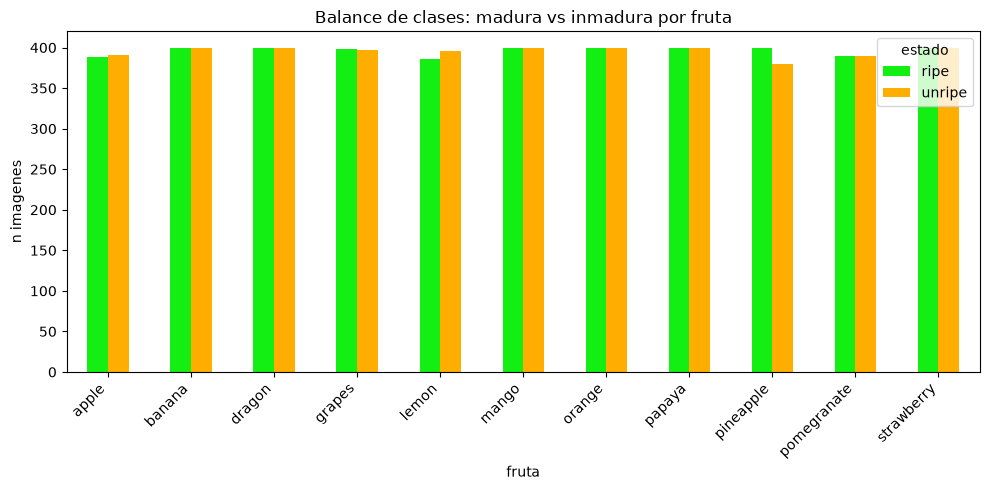

In [20]:
tabla_pivote.plot(kind="bar", figsize=(10, 5), color=["#13EF13", "#ffae00"])
plt.ylabel("n imagenes")
plt.title("Balance de clases: madura vs inmadura por fruta")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 2. Formato, resolución y modo de color

In [21]:
extensiones = collections.Counter()
modos = collections.Counter()
tamanos = collections.Counter()
corruptos = []
dimensiones = []

todos_archivos = []
for clase in sorted(os.listdir(Ruta_imagenes)):
    ruta_clase = os.path.join(Ruta_imagenes, clase)
    if not os.path.isdir(ruta_clase):
        continue
    for nombre_archivo in os.listdir(ruta_clase):
        todos_archivos.append(os.path.join(ruta_clase, nombre_archivo))

for ruta in todos_archivos:
    extension = os.path.splitext(ruta)[1].lower()
    extensiones[extension] += 1
    try:
        with Image.open(ruta) as img:
            img.verify()
        with Image.open(ruta) as img:
            modos[img.mode] += 1
            tamanos[img.size] += 1
            dimensiones.append(img.size)
    except Exception as e:
        corruptos.append((ruta, str(e)))

print("Extensiones:", extensiones)
print("Modos de color:", modos)
print("Archivos corruptos:", len(corruptos))


Extensiones: Counter({'.jpg': 8713})
Modos de color: Counter({'RGB': 8658, 'P': 55})
Archivos corruptos: 0


In [22]:
anchos = [ancho for ancho, alto in dimensiones]
altos = [alto for ancho, alto in dimensiones]
print(f"Ancho: min {min(anchos)}, max {max(anchos)}, avg {statistics.mean(anchos):.1f}, mediana {statistics.median(anchos)}")
print(f"Alto:  min {min(altos)}, max {max(altos)}, avg {statistics.mean(altos):.1f}, mediana {statistics.median(altos)}")


Ancho: min 11, max 162, avg 145.9, mediana 162
Alto:  min 36, max 140, avg 119.4, mediana 119


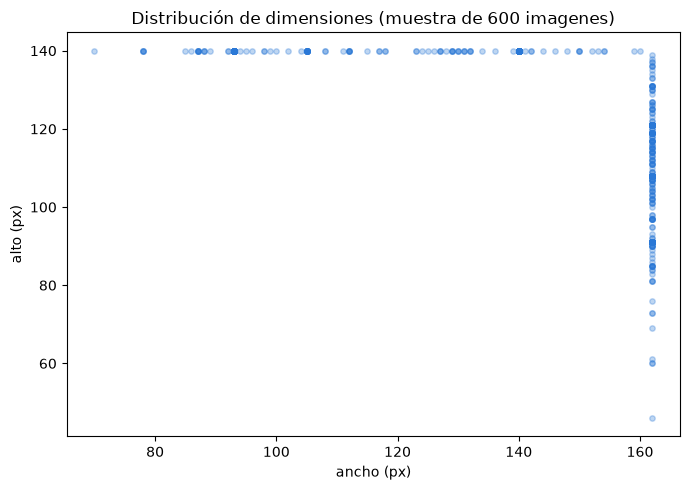

In [23]:
muestra = random.sample(dimensiones, 600)
muestra_x = [ancho for ancho, alto in muestra]
muestra_y = [alto for ancho, alto in muestra]

plt.figure(figsize=(7, 5))
plt.scatter(muestra_x, muestra_y, alpha=0.3, s=15, color="#2a78d6")
plt.xlabel("ancho (px)")
plt.ylabel("alto (px)")
plt.title("Distribución de dimensiones (muestra de 600 imagenes)")
plt.tight_layout()
plt.show()


## 3. Duplicados exactos y label noise

In [24]:
hashes = collections.defaultdict(list)
for ruta in todos_archivos:
    with open(ruta, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    clase = os.path.basename(os.path.dirname(ruta))
    hashes[h].append((clase, ruta))

grupos_duplicados = {h: v for h, v in hashes.items() if len(v) > 1}
archivos_extra = sum(len(v) - 1 for v in grupos_duplicados.values())
cruce_clases = {h: v for h, v in grupos_duplicados.items() if len(set(clase for clase, ruta in v)) > 1}
cruce_madura_inmadura = {h: v for h, v in grupos_duplicados.items() if len(set(clase.split()[0] for clase, ruta in v)) > 1}

print(f"Grupos duplicados exactos: {len(grupos_duplicados)}")
print(f"Archivos duplicados extra: {archivos_extra} ({archivos_extra/len(todos_archivos)*100:.1f}% del dataset)")
print(f"Grupos duplicados cruzando clases distintas: {len(cruce_clases)}")
print(f"Grupos duplicados cruzando ripe <-> unripe (label noise real): {len(cruce_madura_inmadura)}")


Grupos duplicados exactos: 1511
Archivos duplicados extra: 1675 (19.2% del dataset)
Grupos duplicados cruzando clases distintas: 210
Grupos duplicados cruzando ripe <-> unripe (label noise real): 175


In [25]:
# Ejemplos de label noise: mismo archivo pixel-a-pixel con labels ripe y unripe distintos
list(cruce_madura_inmadura.values())[:10]


[[('ripe apple', 'Ripe & Unripe Fruits/ripe apple/82.jpg'),
  ('unripe apple', 'Ripe & Unripe Fruits/unripe apple/113.jpg')],
 [('ripe apple', 'Ripe & Unripe Fruits/ripe apple/89.jpg'),
  ('unripe apple', 'Ripe & Unripe Fruits/unripe apple/94.jpg')],
 [('ripe apple', 'Ripe & Unripe Fruits/ripe apple/234.jpg'),
  ('unripe apple', 'Ripe & Unripe Fruits/unripe apple/282.jpg')],
 [('ripe apple', 'Ripe & Unripe Fruits/ripe apple/171.jpg'),
  ('unripe apple', 'Ripe & Unripe Fruits/unripe apple/259.jpg'),
  ('unripe apple', 'Ripe & Unripe Fruits/unripe apple/302.jpg')],
 [('ripe apple', 'Ripe & Unripe Fruits/ripe apple/141.jpg'),
  ('unripe apple', 'Ripe & Unripe Fruits/unripe apple/68.jpg')],
 [('ripe apple', 'Ripe & Unripe Fruits/ripe apple/369.jpg'),
  ('ripe mango', 'Ripe & Unripe Fruits/ripe mango/17.jpg'),
  ('ripe orange', 'Ripe & Unripe Fruits/ripe orange/262.jpg'),
  ('unripe mango', 'Ripe & Unripe Fruits/unripe mango/76.jpg')],
 [('ripe apple', 'Ripe & Unripe Fruits/ripe apple/45.jp

**Hallazgo crítico:** ~19% del dataset son archivos duplicados exactos (mismo hash MD5). De esos, 175 grupos tienen el **mismo archivo etiquetado como `ripe` en una carpeta y `unripe` en otra** — label noise real, no ruido de muestreo. Si esto no se limpia:

- Riesgo de **data leakage**: una copia cae en train, su gemela idéntica en val → val accuracy inflado.
- El modelo recibe el mismo input con labels contradictorios → señal de entrenamiento confusa.

**Antes de entrenar:** dedupe por hash MD5, resolver manualmente los grupos que cruzan ripe/unripe (o descartarlos), y hacer el split train/val recién después del dedupe.

### Limpieza: eliminar duplicados

- Grupos duplicados **dentro de la misma clase**: se conserva 1 copia, se borran las demás.
- Grupos duplicados **que cruzan clases distintas** (label conflictivo, ej. `ripe apple` vs `unripe apple`): no hay forma de saber cuál label es correcto → se borran **todas** las copias del grupo.


In [26]:
a_eliminar = []

for h, entradas in grupos_duplicados.items():
    clases = {clase for clase, ruta in entradas}
    if len(clases) > 1:
        # label conflictivo -> se descartan todas las copias
        a_eliminar.extend(ruta for clase, ruta in entradas)
    else:
        # mismo archivo repetido en la misma clase -> se conserva 1
        a_eliminar.extend(ruta for clase, ruta in entradas[1:])

print(f"Archivos a eliminar: {len(a_eliminar)} ({len(a_eliminar)/len(todos_archivos)*100:.1f}% del dataset)")


Archivos a eliminar: 1885 (21.6% del dataset)


In [29]:
CONFIRMAR_BORRADO = True  

if CONFIRMAR_BORRADO:
    for ruta in a_eliminar:
        os.remove(ruta)
    print(f"Eliminados {len(a_eliminar)} archivos.")
else:
    print("CONFIRMAR_BORRADO=False, no se borro nada. Revisa a_eliminar antes de activar.")


Eliminados 1885 archivos.


## 4. Resumen

In [30]:
resumen = pd.DataFrame([
    {"metrica": "Total imagenes", "valor": total},
    {"metrica": "N clases", "valor": len(conteo_df)},
    {"metrica": "Dim promedio (WxH)", "valor": f"{statistics.mean(anchos):.0f}x{statistics.mean(altos):.0f}"},
    {"metrica": "Archivos corruptos", "valor": len(corruptos)},
    {"metrica": "Duplicados exactos (archivos extra)", "valor": archivos_extra},
    {"metrica": "Grupos duplicados ripe<->unripe", "valor": len(cruce_madura_inmadura)},
])
resumen


,metrica,valor
0,Total imagenes,8713
1,N clases,22
2,Dim promedio (WxH),146x119
3,Archivos corruptos,0
4,Duplicados exactos (archivos extra),1675
5,Grupos duplicados ripe<->unripe,175
